count    16521.000000
mean        31.201184
std         33.315455
min          0.000000
25%          4.300000
50%         15.920000
75%         54.500000
max        148.350000
Name: Tc, dtype: float64


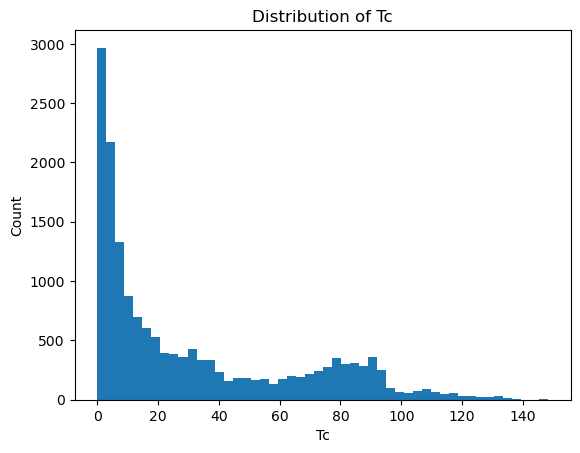

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../archive/featurized.csv")

print(df["Tc"].describe())

plt.hist(df["Tc"], bins=50)
plt.xlabel("Tc")
plt.ylabel("Count")
plt.title("Distribution of Tc")
plt.show()

In [7]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [11]:
corr = df.corr(numeric_only=True)

tc_corr = corr["Tc"].sort_values(ascending=False)

print(tc_corr.head(20))

Tc                                      1.000000
MagpieData avg_dev GSvolume_pa          0.674934
max ionic char                          0.666474
MagpieData range Electronegativity      0.658077
avg ionic char                          0.645520
MagpieData range GSvolume_pa            0.640880
0-norm                                  0.628522
MagpieData avg_dev Electronegativity    0.626278
MagpieData range CovalentRadius         0.619882
MagpieData maximum Electronegativity    0.619555
MagpieData maximum GSvolume_pa          0.614040
MagpieData avg_dev SpaceGroupNumber     0.588289
MagpieData range SpaceGroupNumber       0.582339
MagpieData avg_dev CovalentRadius       0.553096
MagpieData range MendeleevNumber        0.546263
MagpieData range Row                    0.543313
MagpieData avg_dev NdValence            0.540574
MagpieData range Column                 0.529751
MagpieData avg_dev MendeleevNumber      0.524458
MagpieData range NpValence              0.522163
Name: Tc, dtype: flo

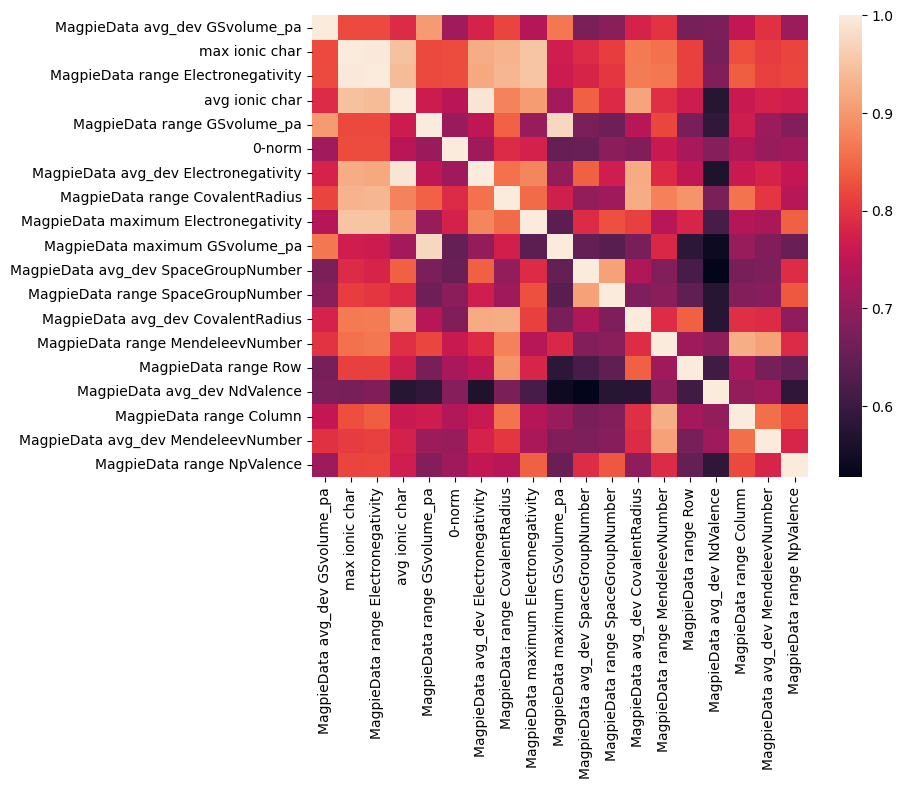

In [12]:
import seaborn as sns

top_features = tc_corr.index[1:20]

plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr())
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["Tc","formula","composition","category"])
y = df["Tc"]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(20))

MagpieData avg_dev GSvolume_pa          0.540132
MagpieData mean NUnfilled               0.110137
MagpieData range CovalentRadius         0.027066
MagpieData mean NsUnfilled              0.015900
MagpieData range Column                 0.015291
MagpieData avg_dev NsUnfilled           0.014739
transition metal fraction               0.012420
MagpieData avg_dev MendeleevNumber      0.009825
MagpieData avg_dev Column               0.008836
MagpieData minimum MendeleevNumber      0.008338
MagpieData mean AtomicWeight            0.007564
MagpieData avg_dev MeltingT             0.007449
2-norm                                  0.007381
MagpieData avg_dev CovalentRadius       0.007213
MagpieData avg_dev NUnfilled            0.007063
MagpieData avg_dev Electronegativity    0.006779
MagpieData avg_dev Number               0.006451
MagpieData mean MeltingT                0.006021
max ionic char                          0.005956
MagpieData avg_dev SpaceGroupNumber     0.005925
dtype: float64


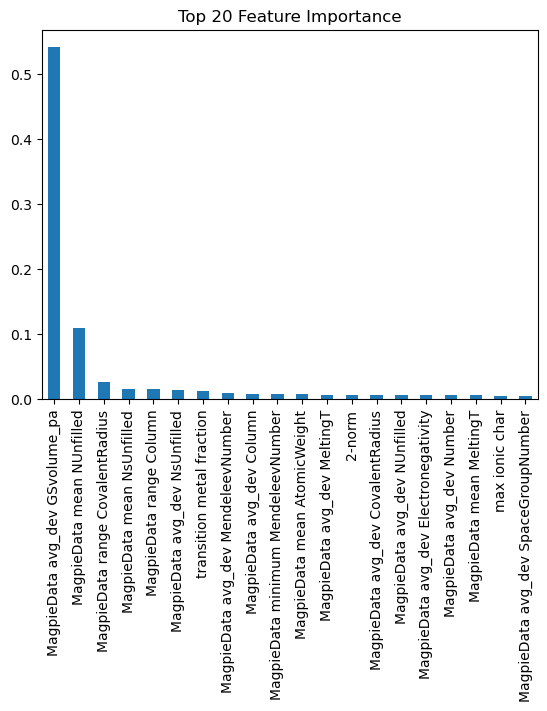

In [15]:
importance.head(20).plot.bar()
plt.title("Top 20 Feature Importance")
plt.show()

In [17]:

import numpy as np
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

X_reduced = X.drop(columns=to_drop)

print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

Original features: 146
Reduced features: 114


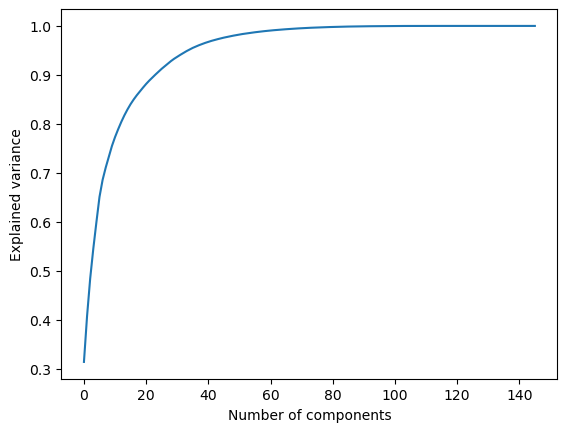

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.show()

In [20]:
df["is_sc"] = (df["Tc"] > 0).astype(int)

print(df["is_sc"].value_counts())

is_sc
1    16463
0       58
Name: count, dtype: int64


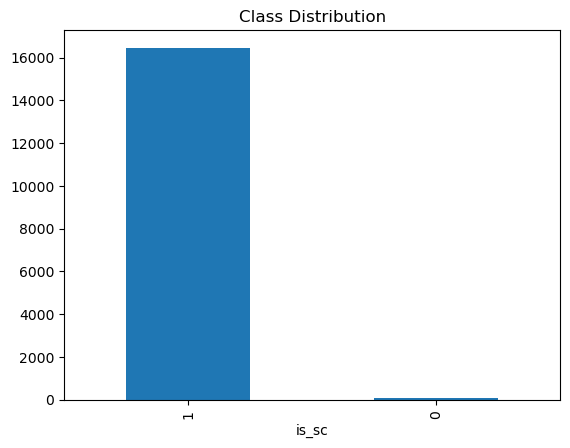

In [21]:
df["is_sc"].value_counts().plot.bar()
plt.title("Class Distribution")
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_reduced)

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print(scores.mean())

-279.28982010799285


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [1]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

e:\anaconda3\envs\my_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'model' is not defined

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [ ]:
shap.plots.scatter(shap_values[:, "mean_atomic_radius"])

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
import numpy as np

importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(30).index